<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/355_groups_comparison.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>


(data-containers-notebook)=
# Contenitori di dati

L'obiettivo del presente capitolo è di introdurre le procedure necessarie per specificare l'input dei dati a PyMC. Ciò ci consentirà anche di estendere la discussione iniziata nel capitolo {ref}`bayes_one_mean_notebook`, focalizzandoci sull'analisi comparativa delle medie di più gruppi indipendenti. 

## Preparazione del Notebook

In [15]:
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pymc as pm
import scipy.stats as stats
import pymc.sampling_jax
import xarray as xr

from numpy.random import default_rng

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = sum(map(ord, "Contenitori di dati"))
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Dati di input in un modello PyMC

Quando costruiamo un modello statistico con PyMC, l'input dei dati è un passaggio cruciale. PyMC è flessibile riguardo ai tipi di dati che si possono utilizzare, accettando una vasta gamma di formati come array di NumPy, serie e DataFrame di pandas, e persino TensorVariables di theano.

Tuttavia, per l'input dei dati nel modello PyMC, l'approccio consigliato è l'utilizzo di uno dei due contenitori di dati specifici di PyMC: `pymc.ConstantData` e `pymc.MutableData`. Questi contenitori offrono diversi vantaggi:

- **Visualizzazione dei dati** come componente del grafico probabilistico.
- **Accesso a dimensioni etichettate** per migliorare la leggibilità e l'accessibilità.
- **Supporto alla sostituzione dei dati** per predizioni fuori campione, interpolazione/extrapolazione, previsioni, ecc.
- **Archiviazione dei dati** in `arviz.InferenceData` per garantire la riproducibilità e facilitare la creazione di grafici.

### Tipi di contenitori di dati in PyMC

**`pymc.ConstantData`**: È utilizzato per aggiungere dati fissi al modello. Offre un vantaggio in termini di velocità sacrificando la flessibilità di potere modificare i dati successivamente. Se non si prevede di cambiare i dati, `ConstantData` è l'opzione preferibile.

**`pymc.MutableData`**: A differenza di `ConstantData`, `MutableData` permette la modifica dei dati, rendendolo ideale per l'inferenza su dati fuori campione o per riutilizzare lo stesso modello con diversi set di dati. Questa flessibilità è particolarmente utile per studi di simulazione o analisi di sensibilità, ma comporta un leggero costo in termini di prestazioni.

### Quando usare `ConstantData` vs `MutableData`

- **Usare `ConstantData`** quando i tuoi dati sono statici e non si prevede di cambiarli tra le varie esecuzioni del modello. Questo è ideale per scenari in cui i dati di input rimangono costanti e si desidera sfruttare il vantaggio in termini di velocità offerto da `ConstantData`.

- **Usare `MutableData`** quando abbiamo bisogno di flessibilità per cambiare i dati tra le esecuzioni del modello. Questo è particolarmente utile per adattare lo stesso modello a diversi set di dati, per la previsione fuori campione o quando i dati di input possono variare nel tempo.

### Esempi e Sintassi

**ConstantData:**

```python
with pm.Model() as model:
    # Supponiamo che `data` sia un array NumPy o un DataFrame pandas
    fixed_data = pm.ConstantData("fixed_data", data)
```

**MutableData:**

```python
with pm.Model() as model:
    # Supponiamo che `data` sia un array NumPy o un DataFrame pandas che vorremmo voler cambiare in seguito
    variable_data = pm.MutableData("variable_data", data)
```

In entrambi i casi, specificare le dimensioni e le coordinate dei dati aiuta a organizzare meglio il modello e a rendere più chiari i grafici probabilistici e le analisi. Utilizzando `ConstantData` o `MutableData`, è anche specificare nomi di dimensioni e coordinate, che migliorano la leggibilità e aiutano a mantenere traccia delle dimensioni dei dati multi-dimensionali, come serie temporali o dati geografici.

### Le coordinate (`coords`) in PyMC

Le coordinate (`coords`) in PyMC (e più in generale in xarray, che è utilizzato da ArviZ per la rappresentazione dei dati inferenziali) sono utilizzate per dare nomi significativi e gestire le dimensioni dei dati. Questo è particolarmente utile quando si lavora con dati multidimensionali o quando si vuole mantenere traccia di categorie specifiche.

### Esempio di Utilizzo delle Coordinate

In questo tutorial useremo i dati relativi ai pinguini Palmer, che verranno letti da un file csv, escludendo le osservazini che presentano valori mancanti:

In [3]:
penguins = pd.read_csv("../data/penguins.csv")
# Subset to the columns needed
missing_data = penguins.isnull()[
    ["bill_length_mm", "flipper_length_mm", "sex", "body_mass_g"]
].any(axis=1)
# Drop rows with any missing data
penguins = penguins.loc[~missing_data]
penguins.shape

(333, 8)

In [4]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [5]:
penguins.tail()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009
343,Chinstrap,Dream,50.2,18.7,198.0,3775.0,female,2009


Nella discussione seguente ci focalizzeremo sul peso `body_mass_g` in funzione della specie:

In [32]:
summary_stats = (
    penguins.loc[:, ["species", "body_mass_g"]]
    .groupby("species")
    .aggregate(["mean", "std", "count"])
)
summary_stats.round(1)

body_mass_g             
                 mean    std count
species                           
Adelie         3706.2  458.6   146
Chinstrap      3733.1  384.3    68
Gentoo         5092.4  501.5   119

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


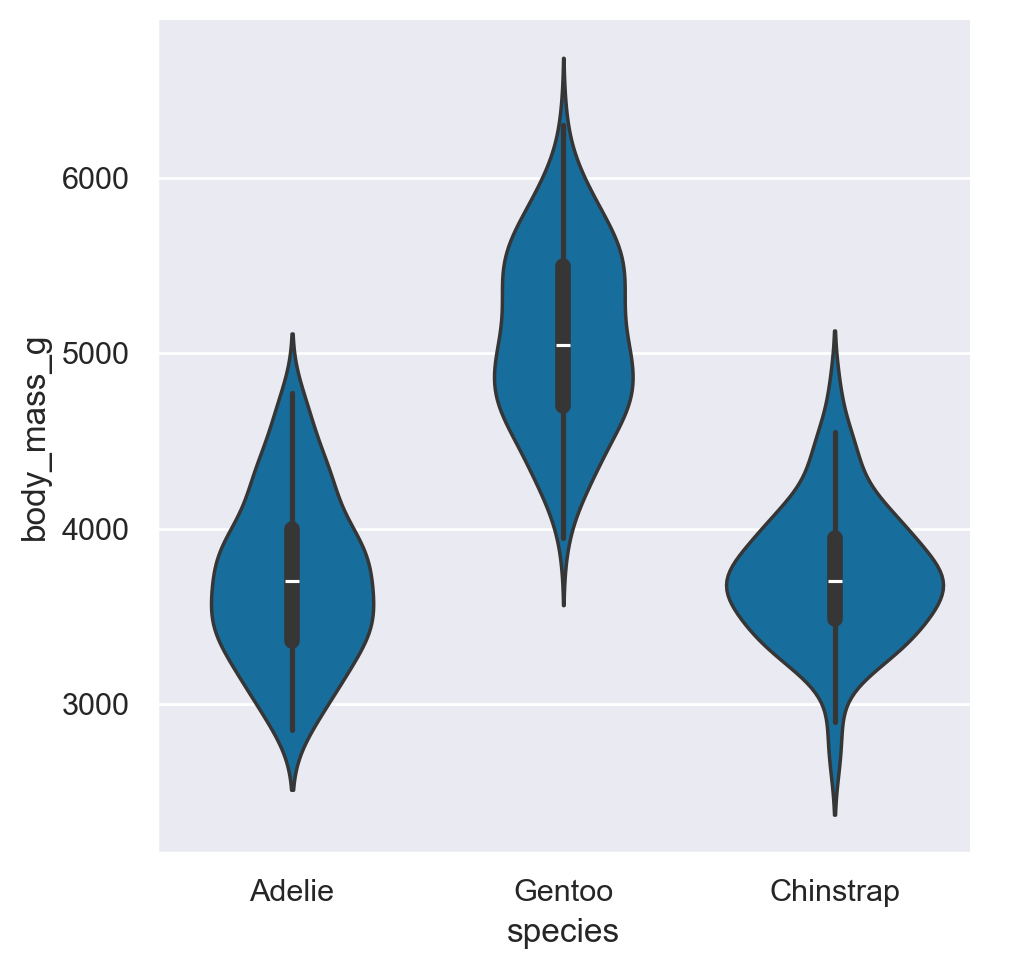

In [35]:
sns.catplot(kind="violin", data=penguins, x="species", y="body_mass_g")

Per tutte le osservazioni, la media e deviazione standard della massa corporea sono le seguenti.

In [10]:
[penguins["body_mass_g"].mean(), penguins["body_mass_g"].std()]

[4207.057057057057, 805.2158019428964]

Immaginiamo di voler creare modelli distinti per analizzare i dati relativi a diverse specie di pinguini. L'obiettivo è informare PyMC che i dati sono suddivisi in tre categorie: Adelie, Gentoo e Chinstrap. Per fare ciò, possiamo utilizzare un dizionario.

```python
coords = {"species": ["Adelie", "Gentoo", "Chinstrap"]}
```

In questa dichiarazione, `coords` è un dizionario che stabilisce una dimensione chiamata `"species"` con tre categorie: `"Adelie"`, `"Gentoo"`, e `"Chinstrap"`. Questo permette di associare dati specifici a ciascuna di queste categorie in modo ordinato.

Il modello PyMC può poi procedere con:

```python
with pm.Model(coords=coords) as model:
    species_idx = pm.ConstantData(
        "species_idx",
        penguins["species"].replace({"Adelie": 0, "Gentoo": 1, "Chinstrap": 2}).values,
    )
```

Iniziamo definendo un modello PyMC `model`, specificando le coordinate `coords`. Ciò significa che passiamo al modello le informazioni relative alle dimensioni e alle categorie che saranno utilizzate.

All'interno del modello, utilizziamo `pm.ConstantData` per creare la variabile `species_idx`. Questa variabile trasforma i nomi delle specie (che provengono dalla colonna `species` nel DataFrame `penguins`) in indici numerici. Il metodo `.replace({"Adelie": 0, "Gentoo": 1, "Chinstrap": 2})` mappa ciascun nome di specie al suo indice corrispondente, basato sull'ordine definito in `coords`.

Questo passaggio è fondamentale per i modelli che lavorano con dati categorici, poiché converte le categorie in forme numeriche che possono essere gestite più facilmente in calcoli statistici o matematici.

L'utilizzo di `coords` e `ConstantData` ha diversi vantaggi:

- **Leggibilità**: Specificare esplicitamente le categorie rende il codice più leggibile e facilita la comprensione del modello e dei dati su cui opera.
- **Gestione dei dati categorici**: Convertire categorie in indici numerici è un passo comune nella preparazione dei dati per la modellazione statistica. L'approccio mostrato qui rende questo processo chiaro e riproducibile.
- **Integrazione con ArviZ e xarray**: Definendo le coordinate, i dati inferenziali risultanti possono essere facilmente esplorati e visualizzati utilizzando strumenti che comprendono le dimensioni e le coordinate, come ArviZ, migliorando ulteriormente l'analisi e la presentazione dei risultati.

In sintesi, l'approccio mostrato nell'esempio illustra una pratica robusta per gestire dati categorici e multidimensionali in PyMC, sfruttando le funzionalità offerte dalle coordinate e dai contenitori di dati come `ConstantData` per migliorare la struttura, la leggibilità e la flessibilità dei modelli bayesiani.

In [36]:
coords = {"species": ["Adelie", "Gentoo", "Chinstrap"]}

with pm.Model(coords=coords) as model:
    # Aggiornato per utilizzare il metodo `map` per la trasformazione dei dati
    species_idx = pm.ConstantData(
        "species_idx",
        penguins["species"].map({"Adelie": 0, "Gentoo": 1, "Chinstrap": 2}).values,
    )

    # Prior normali per mu e sigma per ogni specie
    mu = pm.Normal("mu", 4200, 1000, dims="species")
    sigma = pm.HalfNormal("sigma", 500, dims="species")

    # Likelihood
    y = pm.Normal(
        "y",
        mu=mu[species_idx],
        sigma=sigma[species_idx],
        observed=penguins["body_mass_g"],
    )

Il modello sfrutta le coordinate (`coords`) e `ConstantData` per gestire in modo efficiente e chiaro i dati categorici, in questo caso, le specie di pinguini. Vediamo i dettagli del modello e come viene strutturato.

### Coords e ConstantData

- **Coords**: Le coordinate vengono definite come `{"species": ["Adelie", "Gentoo", "Chinstrap"]}`, che stabilisce un insieme di categorie per una dimensione chiamata `species`. Questo approccio è utile per associare esplicitamente i dati a specifiche categorie, in questo caso, le specie di pinguini.

- **ConstantData**: La variabile `species_idx` viene creata come `ConstantData`, mappando i nomi delle specie presenti nel DataFrame `penguins` in indici numerici (`0` per "Adelie", `1` per "Gentoo", e `2` per "Chinstrap"). Questo trasforma efficacemente i dati categorici in una forma che può essere gestita dal modello.

### Priors Normali e HalfNormal

- **Mu (μ)**: Viene definito un prior normale per la media (`mu`) della massa corporea per ogni specie, con una media ipotetica di 4200 grammi e uno scarto standard di 1000 grammi. L'uso del parametro `dims="species"` indica che `mu` è un vettore di dimensione 3 (una media per ciascuna delle tre specie), associato alle categorie definite in `coords`.

- **Sigma (σ)**: Analogamente, `sigma` rappresenta lo scarto standard della massa corporea per ogni specie, con un prior HalfNormal (che garantisce valori positivi) con un parametro di scala di 500 grammi. Anche in questo caso, `dims="species"` associa ogni valore di `sigma` a una specifica specie.

### Likelihood

- **Y**: La likelihood del modello viene definita attraverso una distribuzione normale, dove `mu` e `sigma` sono indicizzati in base a `species_idx`. Questo significa che per ogni osservazione di massa corporea (`observed=penguins["body_mass_g"]`), il modello utilizza il valore di `mu` e `sigma` corrispondente alla specie di quel particolare pinguino. In altre parole, il modello riconosce e tratta separatamente le tre specie, assegnando a ciascuna le sue specifiche distribuzioni di massa corporea basate sui dati osservati.

Questo esempio dimostra un utilizzo di PyMC per modellare dati complessi che includono variabili categoriche. Utilizzando `coords` e `ConstantData`, il modello può facilmente distinguere tra le specie di pinguini, assegnando a ciascuna delle specie parametri specifici che riflettono le loro caratteristiche uniche nella distribuzione della massa corporea. 

### Indici per i Gruppi

Gli indici contenuti nella variabile `species_idx` servono per associare ogni osservazione del peso corporeo dei pinguini, rappresentato da `penguins["body_mass_g"]`, alla specie di pinguino corrispondente. Questa informazione viene utilizzata nel calcolo della verosimiglianza nel modello, specificata dalla funzione `pm.Normal`. In altre parole, `species_idx` indica a quale delle tre specie di pinguini (Adelie, Gentoo o Chinstrap) appartiene ciascuna delle 333 osservazioni del dataset.

Per chiarire il ruolo di `species_idx`, stampiamo questi valori creando un array ad hoc al di fuori di `pm.Model`.

In [37]:
# Definizione del mapping tra le specie e i loro indici corrispondenti
species_to_index = {"Adelie": 0, "Gentoo": 1, "Chinstrap": 2}

# Utilizzo del metodo .map() per convertire i nomi delle specie in indici
species_idx_values = penguins["species"].map(species_to_index).values

# Stampa dei valori risultanti
print(species_idx_values)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


Visualizziamo la struttura del modello.

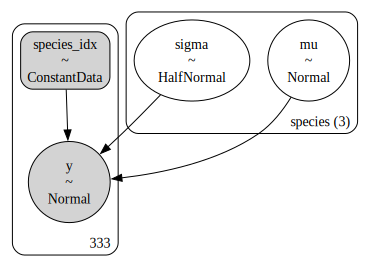

In [38]:
pm.model_to_graphviz(model)

Esaminiamo la distribuzione predittiva a priori.

In [39]:
with model:
    idata_prior = pm.sample_prior_predictive(random_seed=RANDOM_SEED)

Sampling: [mu, sigma, y]


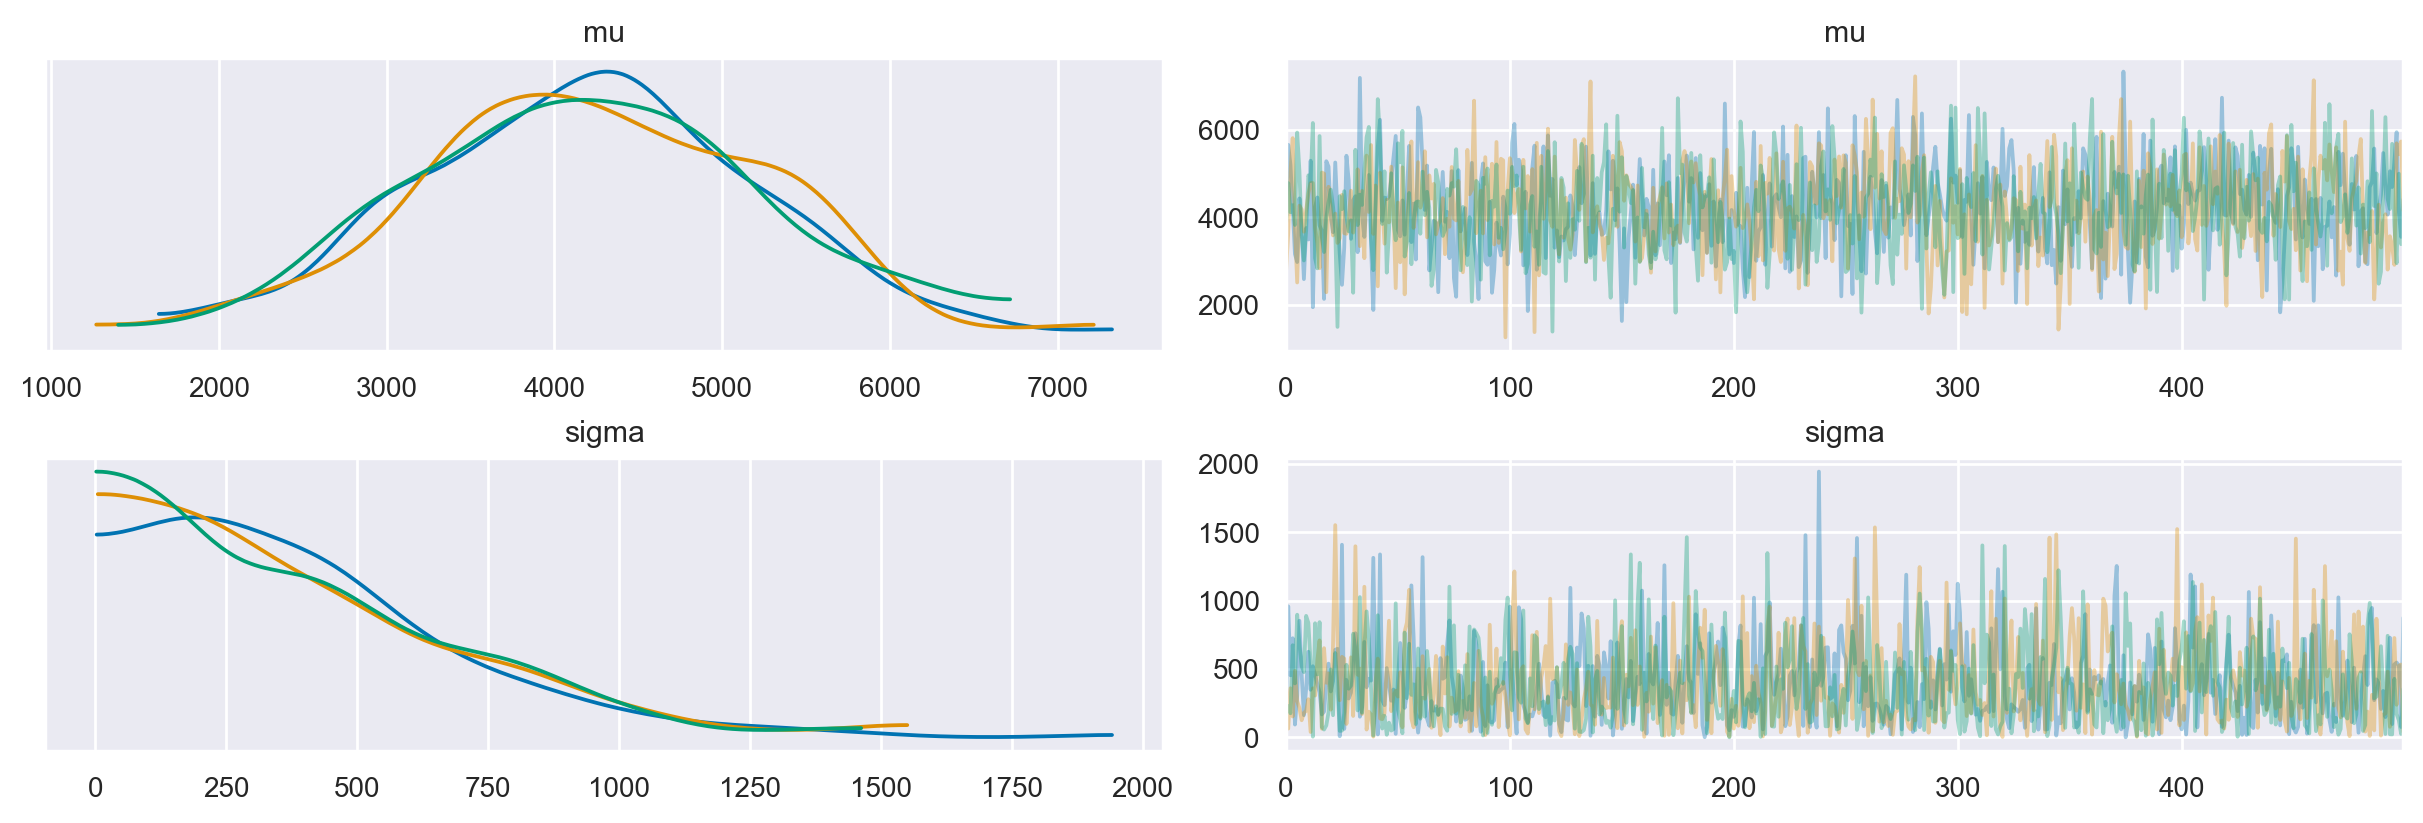

In [13]:
_ = az.plot_trace(idata_prior.prior)

Eseguiamo il campionamento.

In [16]:
with model:
    idata = pm.sampling_jax.sample_numpyro_nuts(idata_kwargs={"log_likelihood": True})

Compiling...


Compilation time = 0:00:01.210141
Sampling...
Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 0:   5%|▌         | 100/2000 [00:01<00:04, 398.72it/s]


Running chain 3: 100%|██████████| 2000/2000 [00:01<00:00, 1076.40it/s]
Sampling time = 0:00:02.255658
Transforming variables...
Transformation time = 0:00:00.077565
Computing Log Likelihood...
Log Likelihood time = 0:00:00.154872


Esaminiamo le distribuzioni a posteriori e le diagnostiche del campionamento.

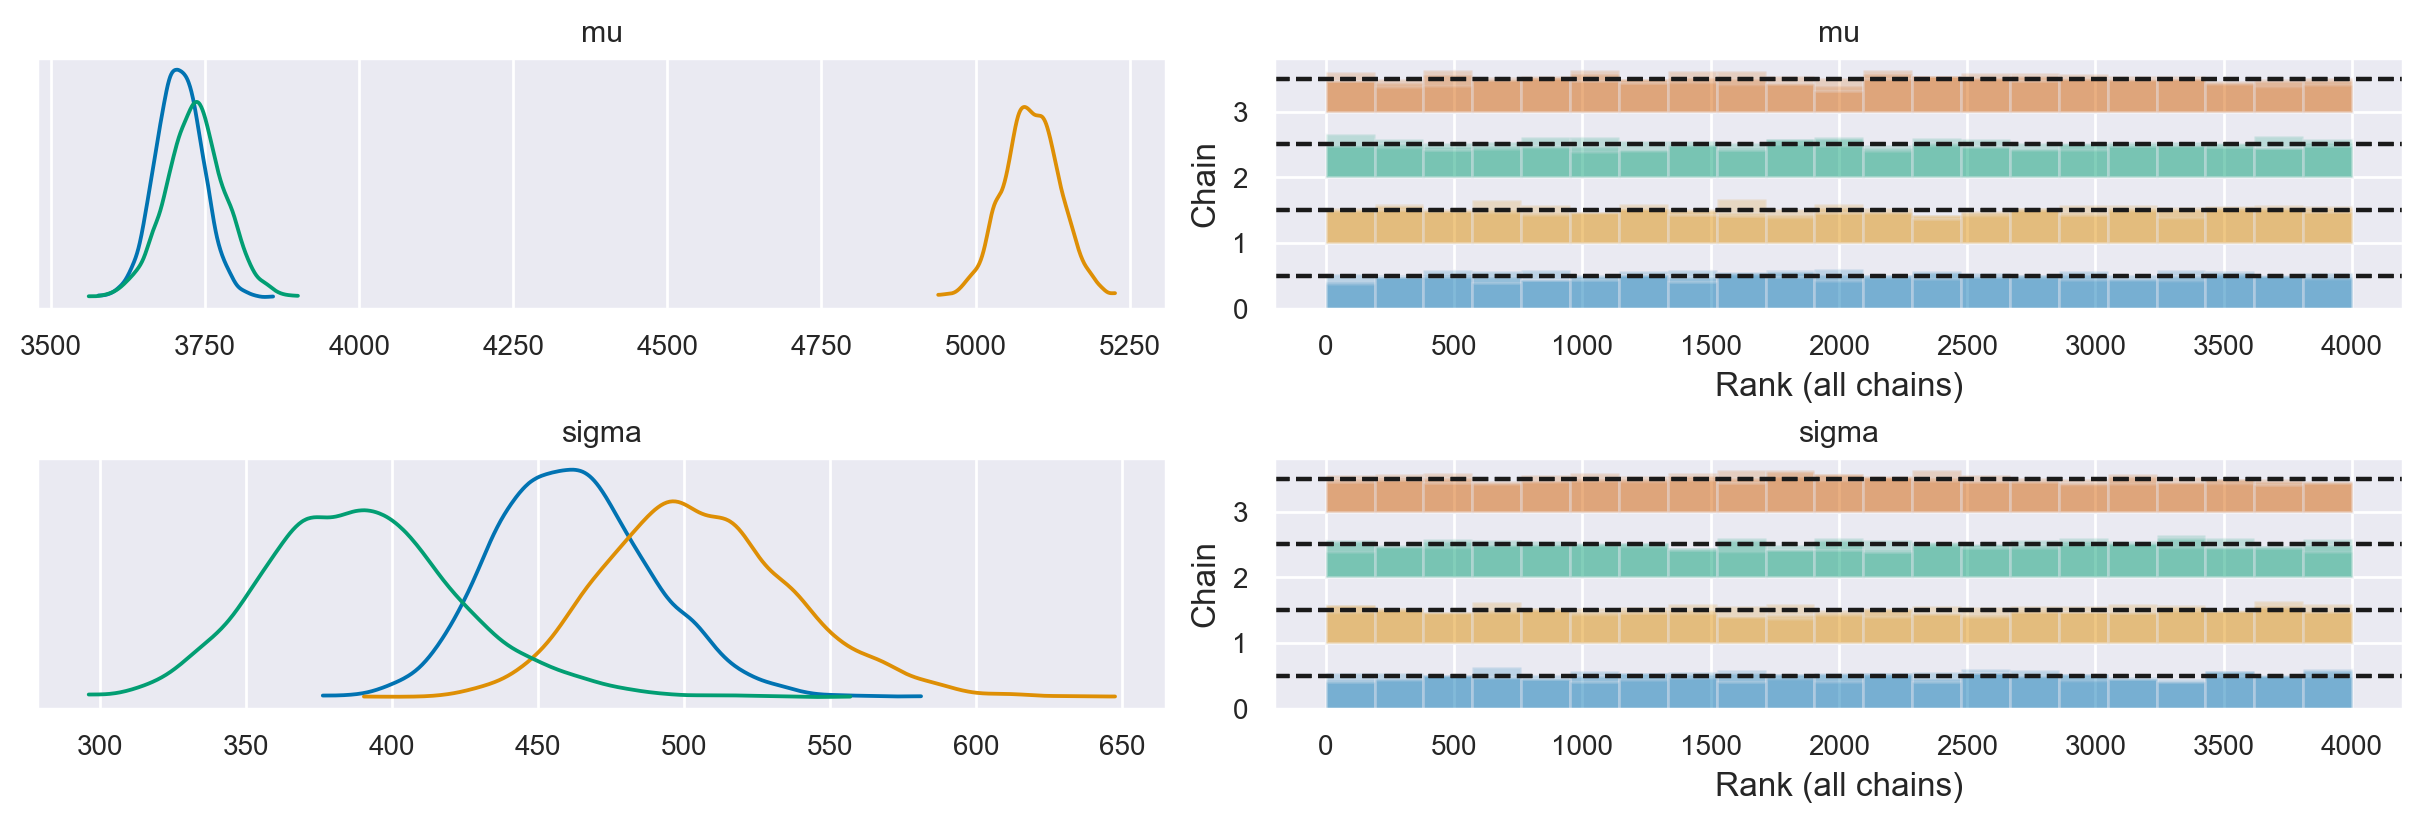

In [17]:
axes = az.plot_trace(idata, combined=True, kind="rank_bars")

Abbiamo ottenuto tre distribuzioni a posteriori per ciascuno dei due parametri $\mu$ e $\sigma$, una distribuzione per ciascuna specie di pinguini.

Un sommario numerico delle distribuzioni a posteriori si ottiene nel modo seguente.

In [18]:
az.summary(idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[Adelie],3707.621,37.756,3638.372,3780.820,0.541,0.383,4866.0,3060.0,1.0
mu[Gentoo],5089.786,45.618,5002.582,5174.408,0.614,0.434,5482.0,3296.0,1.0
mu[Chinstrap],3733.642,48.278,3637.505,3821.826,0.616,0.436,6144.0,2966.0,1.0
sigma[Adelie],461.818,27.009,413.058,512.149,0.360,0.259,5957.0,2965.0,1.0
sigma[Gentoo],505.186,32.790,447.798,569.832,0.408,0.292,6575.0,3244.0,1.0
sigma[Chinstrap],389.457,33.590,327.279,452.422,0.468,0.337,5258.0,3046.0,1.0


Confrontiamo la media a posteriori del parametro $\mu$ con le medie del peso dei tre campioni di pinguini.

In [19]:
summary_stats = (
    penguins.loc[:, ["species", "body_mass_g"]]
    .groupby("species")
    .aggregate(["mean", "std", "count"])
)
summary_stats.round(1)

body_mass_g             
                 mean    std count
species                           
Adelie         3706.2  458.6   146
Chinstrap      3733.1  384.3    68
Gentoo         5092.4  501.5   119

Nell'analisi bayesiana, le medie a posteriori dei parametri $ \mu $ per ciascuna delle tre specie di pinguini convergono verso le medie campionarie. L'elemento distintivo dell'approccio bayesiano è la quantificazione dell'incertezza associata a queste stime, che qui è espressa attraverso gli intervalli di credibilità al 94%.

Dall'osservazione delle distribuzioni a posteriori e dei corrispondenti intervalli di credibilità, possiamo inferire i seguenti punti:

1. **Similarità tra Adelie e Chinstrap**: Le distribuzioni a posteriori delle medie dei pesi per le specie Adelie e Chinstrap sono largamente sovrapposte. Questo suggerisce che le differenze nel peso medio tra queste due specie non sono statisticamente credibili.

2. **Distinzione dei Gentoo**: Al contrario, la distribuzione a posteriori del peso medio per la specie Gentoo è notevolmente disgiunta da quelle delle altre due specie, indicando che i pinguini Gentoo sono generalmente più pesanti.

3. **Variabilità del Peso**: L'analisi delle distribuzioni a posteriori dei parametri $ \sigma $ rivela che il peso dei pinguini Gentoo presenta una maggiore variabilità, seguito dai pinguini Adelie e infine dai pinguini Chinstrap. Questo è corroborato dall'ampiezza degli intervalli di credibilità per $ \sigma $ nelle tre specie.

In sintesi, l'analisi Bayesiana fornisce non solo una stima puntuale dei parametri di interesse, ma anche una misura robusta dell'incertezza associata a queste stime, permettendo un'interpretazione più completa e informativa dei dati.

## Test d'ipotesi bayesiane

Dopo aver effettuato il campionamento dalla distribuzione a posteriori del parametro $ \mu $ per ogni specie di pinguino, è naturale indagare sulla probabilità che il peso medio di una specie sia maggiore rispetto a un'altra. Questa domanda può essere affrontata mediante l'analisi comparativa delle distribuzioni a posteriori. In particolare, si può procedere estraendo campioni casuali dai posteriori e confrontando le corrispondenti realizzazioni del parametro $ \mu $ tra le diverse specie.

L'ispezione delle proprietà di `idata` fornisce informazioni dettagliate sui campioni a posteriori, che possono essere utilizzate per ulteriori analisi e interpretazioni statistiche.

In [20]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data
	> constant_data

Recuperiamo i valori a posteriori del parametro $\mu$.

In [21]:
mu_post = idata.posterior['mu']

L'oggetto ottenuto è un array di dimensioni $4 \times 1000 \times 3$. L'indice 4 si riferisce alle catente, l'indice 1000 si riferisce al numero di campioni ottenuti, l'indice 3 si riferisce ai gruppi. 

In [22]:
mu_post.shape

(4, 1000, 3)

Per trovare la media a posteriori del parametro $\mu$ della specie Adelie prendiamo le osservazioni che si riferiscono a tutte le catene (:), a tutti i valori campionati (:) per il primo gruppo (0). La media a posteriori dei pinguini Adelie è dunque uguale a

In [23]:
print(mu_post[:, :, 0].mean())

<xarray.DataArray 'mu' ()>
array(3707.62088323)
Coordinates:
    species  <U9 'Adelie'


Per tutte e tre le specie (Adelie, Gentoo, Chinstrap) abbiamo

In [25]:
np.array(
    [mu_post[:, :, 0].mean(), mu_post[:, :, 1].mean(), mu_post[:, :, 2].mean()]
).round(1)

array([3707.6, 5089.8, 3733.6])

Per verificare che l'ordinamento dei gruppi corrisponda a Adelie, Gentoo, Chinstrap, esaminiamo la stima a posteriori della deviazione standard delle tre specie. 

In [26]:
sigma_post = idata.posterior["sigma"]
np.array(
    [sigma_post[:, :, 0].mean(), sigma_post[:, :, 1].mean(), sigma_post[:, :, 2].mean()]
).round(1)

array([461.8, 505.2, 389.5])

I valori trovati confermano quello che ci aspettavamo. Ora che abbiamo capito come estrarre le stime a posteriori di un parametro per ciascun gruppo, possiamo passare al test di ipotesi bayesiano.
Chiediamoci quale sia la probabilità che un pinguino Adelie abbia un peso minore di un pinguino Chinstrap.

In [27]:
np.mean([mu_post[:, :, 0] < mu_post[:, :, 1]])

1.0

Qual è la probabilità che un pinguino Adelie abbia un peso minore di un pinguino Gentoo?

In [28]:
np.mean([mu_post[:, :, 0] < mu_post[:, :, 2]])

0.66375

Qual è la probabilità che un pinguino Chinstrap abbia un peso minore di un pinguino Gentoo?

In [29]:
np.mean([mu_post[:, :, 1] < mu_post[:, :, 2]])

0.0

Consideriamo ora la variabilità. Troviamo la probabilità che la deviazione standard del peso dei pinguini Adelie sia minore di quella dei pinguini Chinstrap.

In [30]:
np.mean([sigma_post[:, :, 0] < sigma_post[:, :, 2]])

0.053

## Commenti e considerazioni finali 

In questo capitolo, abbiamo esaminato l'uso dei contenitori di dati per l'inferenza parametrica applicata a distribuzioni normali in scenari con gruppi di dati indipendenti. Nei capitoli successivi, ci sposteremo verso un quadro analitico diverso, particolarmente pertinente quando si presume che i gruppi in esame siano istanze specifiche di una categoria generale e sottostante. Questa prospettiva è formalizzata attraverso l'uso di modelli gerarchici bayesiani, una metodologia frequentemente impiegata nel campo della psicologia.

## Watermark

In [31]:
%load_ext watermark
%watermark -n -u -v -iv -m -p jax

Last updated: Fri Feb 23 2024

Python implementation: CPython
Python version       : 3.11.7
IPython version      : 8.21.0

jax: 0.4.23

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

scipy     : 1.12.0
pymc      : 5.10.4
numpy     : 1.26.4
pandas    : 2.2.0
arviz     : 0.17.0
xarray    : 2024.1.1
matplotlib: 3.8.2
seaborn   : 0.13.2

